In [1]:
import heyoka as hk

import numpy as np
import matplotlib.pyplot as plt

# We will need torch for this notebook. The CPU version is enough though.
import torch
from torch import nn
import sys
sys.path.append('../') # add parent directory to path to import eclipsenets
import eclipsenets as en
torch.set_default_dtype(torch.float64)

## Heyoka and Torch

First, let's make sure we load the model from torch correctly.

Let's load the torch model..

In [2]:
hidden_features=32
hidden_layers=2
model = en.SIREN(in_features=6, 
              hidden_features=hidden_features, 
              hidden_layers=hidden_layers, 
              out_features=1, 
              outermost_linear=True
              ).to('cpu')
device = torch.device('cpu')
#model_path="../models/smaller_nets/chu-ger_model_loss_siren_4_38__2.4351573301828466e-05.pt"#None
# model_path="../models/ffnn_vs_siren/chu-ger_model_siren_2_32__loss_train_4.64686490886379e-05_and_loss_valid_4.94075684400741e-05.pt"#None
# model_path='../models/ffnn_vs_siren/itokawa_model_siren_2_32__loss_train_4.708245978690684e-05_and_loss_valid_4.986285057384521e-05.pt'
model_path='../models/ffnn_vs_siren/bennu_model_siren_2_32__loss_train_1.9905979570467025e-05_and_loss_valid_2.1772848413093016e-05.pt'
# model_path = '../models/ffnn_vs_siren/eros_model_siren_2_32__loss_train_4.2136525735259056e-05_and_loss_valid_4.584954513120465e-05.pt'
if model_path is not None:
    model.load_state_dict(torch.load(model_path,
                                     map_location=device.type))
model.eval()


SIREN(
  (net): Sequential(
    (0): SineLayer(
      (linear): Linear(in_features=6, out_features=32, bias=True)
    )
    (1): SineLayer(
      (linear): Linear(in_features=32, out_features=32, bias=True)
    )
    (2): SineLayer(
      (linear): Linear(in_features=32, out_features=32, bias=True)
    )
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Let's flatten the weights & biases in a Heyoka-compatible fashion (see tutorial on Heyoka.py) and load the corresponding heyoka Siren model

In [3]:
#let's flatten the network parameters
flattened_weights = en.weights_and_biases_heyoka(model)

omega_0=30.
linear = lambda inp: inp
sin_layer = lambda inp: hk.sin(omega_0*inp)
cos_az, sin_az, cos_el, sin_el, x_coord, y_coord=hk.make_vars("cos_az","sin_az","cos_el","sin_el","x_coord","y_coord")
model_heyoka=hk.model.ffnn(inputs=[cos_az, sin_az, cos_el, sin_el, x_coord, y_coord], 
                           nn_hidden=[hidden_features]*(hidden_layers+1), 
                           n_out=1,
                           activations=[sin_layer]*(hidden_layers+1)+[linear], 
                           nn_wb=flattened_weights)

#let's compile it
model_heyoka_compiled=hk.cfunc(model_heyoka, [cos_az, sin_az, cos_el, sin_el, x_coord, y_coord])

(2272,)


In [4]:
#let's reconstruct the shape w heyoka:
N_views=10
xyz_dir,az,el=en.fibonacci_sphere(N_views)
x = np.linspace(-1, 1., 300)
y = np.linspace(-1., 1., 300)
X, Y = np.meshgrid(x, y)
input_data=np.zeros((len(X.flatten()),6))
input_data[:,0]=np.repeat(np.cos(az[4]),len(X.flatten()))
input_data[:,1]=np.repeat(np.sin(az[4]),len(X.flatten()))
input_data[:,2]=np.repeat(np.cos(el[4]),len(X.flatten()))
input_data[:,3]=np.repeat(np.sin(el[4]),len(X.flatten()))
input_data[:,4]=X.flatten()
input_data[:,5]=Y.flatten()
out_array=np.zeros((1,len(X.flatten())))
output_heyoka=model_heyoka_compiled(np.ascontiguousarray(input_data.T),outputs=out_array).reshape(X.shape)

Let's now inspect the network inference values for the heyoka and torch model 

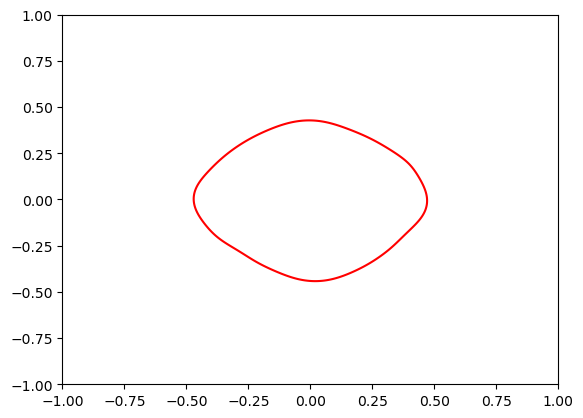

In [5]:
#2d ax
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,1)
ax.contour(X,Y,output_heyoka,levels=1,colors='red')


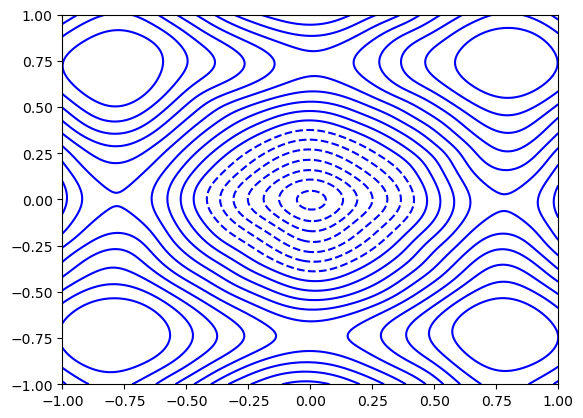

In [6]:
#do the same 2d plot but w torch
#2d ax
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,1)
input_data_torch=torch.tensor(input_data).to(device)
output_torch=model(input_data_torch).detach().numpy().reshape(X.shape)
ax.contour(X,Y,output_torch,levels=20,colors='blue')

All right... the neural network model was indeed reconstructed successfully

## Let's now move to the spacecraft dynamics

In [7]:
import pickle as pk
#first the necessary loadings:
# with open("../3dmeshes/Churyumov-Gerasimenko_raw.pk", "rb") as f:
body_name="Bennu"
with open(f"../3dmeshes/{body_name}_raw.pk", "rb") as f:   
    mesh_points, mesh_triangles = pk.load(f)
if body_name in ["Churyumov-Gerasimenko"]:
    mesh_points = np.array(mesh_points)/1e3
mesh_points = np.array(mesh_points)
mesh_triangles = np.array(mesh_triangles)

#with open("../3dmeshes/Churyumov-Gerasimenko_raw_lp.pk", "rb") as f:
with open(f"../3dmeshes/{body_name}_raw_lp.pk", "rb") as f:   
    mesh_points_lp, mesh_triangles_lp = pk.load(f)
if body_name in ["Churyumov-Gerasimenko"]:
    mesh_points_lp = np.array(mesh_points_lp)/1e3
mesh_points_lp = np.array(mesh_points_lp)
mesh_triangles_lp = np.array(mesh_triangles_lp)

# Characteristic dimension (To know the units of the model, e.g. Eros is in km)
L = max(mesh_points[:,0]) - min(mesh_points[:,0])
mesh_points = mesh_points / L
mesh_points_lp = mesh_points_lp / L
print(f"Units of lenght ({body_name}):", L, "km")
with open(f"../mascons/{body_name}_lp.pk", "rb") as file:
    mascon_points, mascon_masses, mascon_name = pk.load(file)

Units of lenght (Bennu): 0.5634379088878632 km


In [8]:
len(mascon_points),len(mesh_points)

(6225, 7374)

In [9]:
def state2input(position, sun_direction):
    """
    This function takes the spacecraft position and the sun direction 
    and returns the input for the neural network, in a heyoka compatible 
    fashion.

    Args:
        position (3,): spacecraft position in cartesian coordinates
        sun_direction (3,): sun direction in cartesian coordinates

    Returns:
        (6,): input for the neural network
    """
    phi=hk.acos(sun_direction[2])
    theta=hk.atan2(sun_direction[1],sun_direction[0])
    costheta=hk.cos(theta)
    sintheta=hk.sin(theta)
    cosphi=hk.cos(phi)
    sinphi=hk.sin(phi)
    #now the xy coordinates, defined with a reference system coherent with en.project_on_plane
    U=np.array([-sintheta,costheta,0])
    V=np.array([costheta*cosphi, sintheta*cosphi, -sinphi] )
    # Compute the projection
    X = np.dot(position,U)
    Y = np.dot(position,V)
    return [costheta, sintheta, cosphi, sinphi, X, Y]

## Equations of Motion

In [10]:
x, y, z, vx, vy, vz = hk.make_vars("x", "y", "z", "vx", "vy", "vz") 

In [11]:
#as parameters we use:
# 0: eclipse (0 or 1)
# 1: halfplane (0 or 1)
# 2: omega (rotation of the asteroid)
# 3: x-coordinate of initial sun direction around asteroid axis
# 4: y-coordinate of initial sun direction around asteroid axis
# 5: z-coordinate of initial sun direction around asteroid axis
# 6: srp value

# Kinematics
dx = vx
dy = vy
dz = vz
# Dynamics
omega = hk.par[2]
x_sum = []
y_sum = []
z_sum = []
# First the gravitational accelerations
for point,mass in zip(mascon_points, mascon_masses):
    diff_x = x-point[0]
    diff_y = y-point[1]
    diff_z = z-point[2]
    r_m3 = (diff_x*diff_x + diff_y*diff_y + diff_z*diff_z) ** hk.expression(-3. / 2)
    x_sum.append(-mass * r_m3 * diff_x)
    y_sum.append(-mass * r_m3 * diff_y)
    z_sum.append(-mass * r_m3 * diff_z)

# Then solar radiation accelerations (we define magnitude and direction here)
eclipse = hk.par[0]
sd0 = hk.par[3] * hk.cos(omega * hk.time) - hk.par[4] * hk.sin(omega * hk.time)
sd1 = hk.par[3] * hk.sin(omega * hk.time) + hk.par[4] * hk.cos(omega * hk.time)
sd2 = hk.par[5] 

# Assembling
dvx = hk.sum(x_sum) + omega**2*x + 2*omega*vy  - hk.par[7] * eclipse * sd0
dvy = hk.sum(y_sum) + omega**2*y - 2*omega*vx  - hk.par[7] * eclipse * sd1
dvz = hk.sum(z_sum) - hk.par[7] * eclipse * sd2
# ... pack them for heyoka
eqns = [(x, dx), (y, dy), (z, dz), (vx, dvx), (vy, dvy), (vz, dvz)]

### Eclipse Event

In [12]:
def half_plane(ta, d_sgn):
    # We pass on the front (no shadow)
    if d_sgn > 0:
        ta.pars[1] = 0.
        go_on_front.append(ta.time)
    # We pass on the back (shadow)
    if d_sgn < 0:
        ta.pars[1] = 1.
        go_on_back.append(ta.time)
    # Do not stop the integration.
    return True

def too_distant(ta, d_sgn):
    # We are far from the asteroid
    if d_sgn > 0:
        ta.pars[1] = 0.
        go_outside.append(ta.time)
    
    # We are close to the asteroid
    if d_sgn < 0:
        ta.pars[1] = 1.
        go_inside.append(ta.time)
    return True

# The event equation (NN ==0)
def crossing_shadow_cone(x, y, z, ecnet):
    omega = hk.par[2]
    sd0 = hk.par[3] * hk.cos(omega * hk.time) - hk.par[4] * hk.sin(omega * hk.time)
    sd1 = hk.par[3] * hk.sin(omega * hk.time) + hk.par[4] * hk.cos(omega * hk.time)
    sd2 = hk.par[5] 
    sd = np.array([sd0, sd1, sd2])
    nn_in = state2input(np.array([x,y,z]), sd)
    #out=model_heyoka_compiled(nn_in)
    ecnet=hk.subs(ecnet,{"cos_az":nn_in[0],"sin_az":nn_in[1], "cos_el":nn_in[2], "sin_el":nn_in[3], "x_coord":nn_in[4], "y_coord":nn_in[5]})
    return hk.par[1] * ecnet[0] + (1.-hk.par[1])

#an event to check if we are too distant from the asteroid (in which case the NN can return nonsense)
def too_distant_event(x,y,z):
    sd0 = hk.par[3] * hk.cos(omega * hk.time) - hk.par[4] * hk.sin(omega * hk.time)
    sd1 = hk.par[3] * hk.sin(omega * hk.time) + hk.par[4] * hk.cos(omega * hk.time)
    sd2 = hk.par[5] 
    sd = np.array([sd0, sd1, sd2])
    nn_in = state2input(np.array([x,y,z]), sd)
    return (nn_in[-2]**2+nn_in[-1]**2)-1.

# The event equation (halfPlane)
def half_plane_event(x, y, z):
    omega = hk.par[2]
    sd0 = hk.par[3] * hk.cos(omega * hk.time) - hk.par[4] * hk.sin(omega * hk.time)
    sd1 = hk.par[3] * hk.sin(omega * hk.time) + hk.par[4] * hk.cos(omega * hk.time)
    sd2 = hk.par[5] 
    retval = sd0*x + sd1*y + sd2*z
    return retval

half_plane_event_cfunc=hk.cfunc([half_plane_event(x,y,z)],vars=[x,y,z])#(ta2.state[:3],pars=ta2.pars[:6],time=ta2.time)
too_distant_cfunc=hk.cfunc([too_distant_event(x,y,z)],vars=[x,y,z])


def eclipse_event(ta, d_sgn):
    # omega = ta.pars[2]
    # sd0 = ta.pars[3] * np.cos(omega * ta.time) - ta.pars[4] * np.sin(omega * ta.time)
    # sd1 = ta.pars[3] * np.sin(omega * ta.time) + ta.pars[4] * np.cos(omega * ta.time)
    # sd2 = ta.pars[5] 
    # x,y,z,_,_,_ = ta.state
    # half_plane = sd0*x + sd1*y + sd2*z
    half_plane=half_plane_event_cfunc(ta.state[:3],pars=ta.pars[:6],time=ta.time)[0]
    too_distant=too_distant_cfunc(ta.state[:3],pars=ta.pars[:6],time=ta.time)[0]
    if half_plane < 0 and too_distant < 0:
        # We exit from eclipse
        if d_sgn > 0:
            exit_times.append([ta.time, ta.state[:3].copy()])
            ta.pars[0] = 1.
        # We enter eclipse
        if d_sgn < 0:
            enter_times.append([ta.time, ta.state[:3].copy()])
            ta.pars[0] = 0.
    # Do not stop the integration.
    return True

In [13]:
import time
start = time.time()
# Getting in or out of the eclipse cone
ev1 = hk.t_event(
        # The event equation.
        crossing_shadow_cone(x,y,z, model_heyoka),
        # The callback.
        callback = eclipse_event,
        cooldown = 1e-8
    )
end = time.time()
print("Time to construct the heyoka event: ", end-start)

ev2 = hk.t_event(
        # The event equation.
        half_plane_event(x,y,z),
        # The callback.
        callback = half_plane,
        cooldown = 1e-8
    )

ev3=hk.t_event(
    too_distant_event(x,y,z),
    callback=too_distant,
    cooldown=1e-8
)



Time to construct the heyoka event:  0.0009639263153076172


In [14]:
# Construct the integrator.
start = time.time()
ta2 = hk.taylor_adaptive(eqns, 
                         # the list of terminal events. 
                         t_events = [ev1, ev2, ev3],  
                         compact_mode = True)
end = time.time()
print("Time to construct the Taylor integrator (with events): ", end-start)
# ... and the version without events
start = time.time()
ta1 = hk.taylor_adaptive(eqns, compact_mode=True)
end = time.time()
print("Time to construct the Taylor integrator (without events): ", end-start)

Time to construct the Taylor integrator (with events):  1.8543879985809326
Time to construct the Taylor integrator (without events):  1.3324127197265625


In [15]:
start = time.time()
ta3 = hk.taylor_adaptive(eqns, compact_mode=True)
end = time.time()
print("Time to construct the Taylor integrator (with step callback): ", end-start)

Time to construct the Taylor integrator (with step callback):  1.077204942703247


In [16]:
# The callback.
def cb(ta):
    sd0 = ta.pars[3] * np.cos(omega * ta.time) - ta.pars[4] * np.sin(omega * ta.time)
    sd1 = ta.pars[3] * np.sin(omega * ta.time) + ta.pars[4] * np.cos(omega * ta.time)
    sd2 = ta.pars[5] 
    sd=np.array([sd0,sd1,sd2])
    if eclipse_nn(ta.state[0],ta.state[1],ta.state[2],sd,model_heyoka_compiled):
        ta.pars[1] = 0.
    else:
        ta.pars[1] = 1.
    return True

In [17]:
# The direction of the Sun
sun_direction = np.array([-1.,-1.,0.])
sun_direction = sun_direction / np.linalg.norm(sun_direction)

In [18]:
# Angular velocity of the asteroid
G = 6.674e-11 # Units for Cavendish Constant
if body_name=="Churyumov-Gerasimenko":
    Mass = 9.982e12  # Units for
    hr_rotation=12.4043
elif body_name=="Itokawa":
    Mass=3.51e10
    hr_rotation=12.132
elif body_name=="Eros":
    Mass=6.687e15
    hr_rotation=5.27
elif body_name=="Bennu":
    Mass=7.329e10
    hr_rotation=4.296
T = np.sqrt((L*1000)**3/G/Mass) # Units induced on time
omega = 2 * np.pi / ( hr_rotation * 60 * 60) * T #(5.27 hours rotation period)

# Setting initial conditions from an inclination
# Initial inclination of the orbit
incl = 11. / 180. * np.pi
# Initial conditions
r_0=1.5
ic = np.array([-r_0, 0, 0, 0, np.sqrt(r_0) / r_0 * np.cos(incl) + omega*r_0, np.sqrt(r_0) / r_0 * np.sin(incl)])

ta2.state[:] = ic
ta2.time = 0

ta1.state[:] = ic
ta1.time = 0

ta3.state[:] = ic
ta3.time = 0

# Setting parameters
# We set the network weights
# We set the initial umbra-light
ta3.pars[0] = 1
ta2.pars[0] = 1
ta1.pars[0] = 1
# We set the initial halfplane (when in front no eclipse is possible)
hf = np.dot(ic[:3], sun_direction) < 0
ta3.pars[1] = int(hf)
ta2.pars[1] = int(hf)
ta1.pars[1] = int(hf)
# We set the angular velocity
ta3.pars[2] = omega
ta2.pars[2] = omega
ta1.pars[2] = omega

# We set the initial sun direction
ta3.pars[3:6]  = sun_direction
ta2.pars[3:6]  = sun_direction
ta1.pars[3:6]  = sun_direction


# And the SRP value
SRP = 1e-3
ta3.pars[7] = SRP
ta2.pars[7] = SRP
ta1.pars[7] = SRP


# Recording event times
exit_times = []
enter_times = []
go_on_front = []
go_on_back = []
go_outside = []
go_inside = []


In [19]:
tgrid = np.linspace(0, 3.*np.pi,3*80) 

In [20]:
start = time.time()
sol1 = ta1.propagate_grid(tgrid)
end = time.time()
print("Time to propagate with no events: ", end-start)

Time to propagate with no events:  0.432675838470459


In [21]:
sol3 = []
tgrid3 = []
def callback(ta):
    sol3.append(ta.state)
    tgrid3.append(ta.time)
    return True

start = time.time()
sol2 = ta2.propagate_grid(tgrid, callback = callback)
end = time.time()
print("Time to propagate with events: ", end-start)

Time to propagate with events:  4.636484861373901


In [22]:
print("Number of entry points: ", len(enter_times))
print("Number of exit points: ", len(exit_times))

Number of entry points:  8
Number of exit points:  8


In [23]:
# Function to create 3D scatter plots
def create_3d_scatter_plot(ax,mesh):
    # Generate random 3D coordinates
    x = mesh[:,0]#np.random.rand(100)
    y = mesh[:,1]#np.random.rand(100)
    z = mesh[:,2]#np.random.rand(100)
    
    # Scatter plot
    ax.scatter(x, y, z, s=0.09,color='grey')
    ax.set_xlabel('x [-]')
    ax.set_ylabel('y [-]')
    ax.set_zlabel('z [-]')
    ax.view_init(elev=25, azim=45)
    #let's do axis equal
    ax.set_aspect('equal')
    return ax


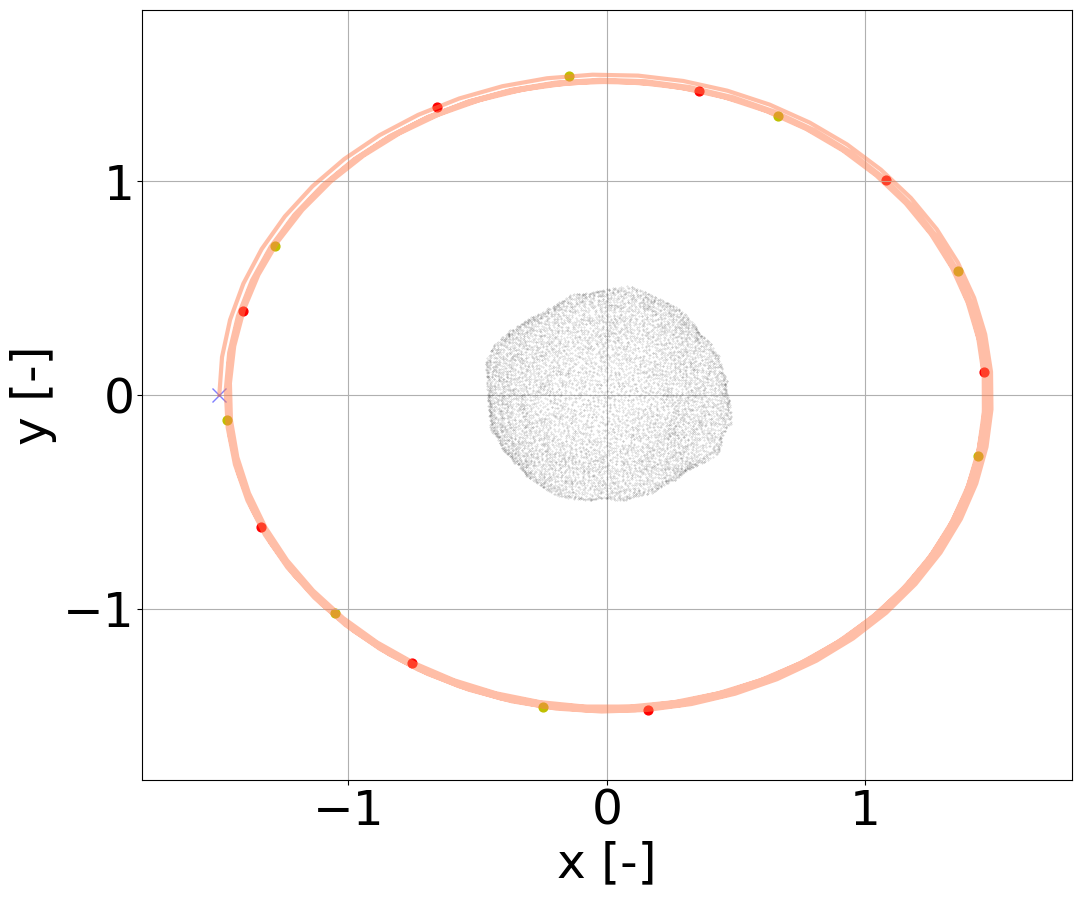

In [24]:
#change fontisze
plt.rcParams.update({'font.size': 35})
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111)

#ax = en.plot_mesh_vertices(mesh_points, 1, s = 1, c='k', alpha=0.1, ax=ax, plot_ref=False, axis_off=False)
two_d=en.project_on_plane(mesh_points,np.array([0,0,1.]))
ax.plot(two_d[0], two_d[1],'x',alpha=0.1,markersize=1.,color='black')
ax.plot(sol2[-1][0,0], sol2[-1][0,1],'x',alpha=0.5,markersize=10.,color='blue')

ax.plot(sol2[-1][:,0], sol2[-1][:,1],  alpha=0.5,linewidth=3.,color='coral')
#ax.plot(sol1[4][:,0], sol1[4][:,1], sol1[4][:,2], 'g')
for idx,t in enumerate(enter_times):
    if idx==0:   
        ax.scatter(t[1][0], t[1][1], s = 40, c = 'r',label='entry')
    else:
        ax.scatter(t[1][0], t[1][1], s = 40, c = 'r')
for idx,t in enumerate(exit_times):
    if idx==0:
        ax.scatter(t[1][0], t[1][1], s = 40, c = 'y',label='exit')
    else:
        ax.scatter(t[1][0], t[1][1], s = 40, c = 'y')

#ax.legend()
ax.set_xlim([-1.8,1.8])
ax.set_ylim([-1.8,1.8])
ax.set_xlabel('x [-]')
ax.set_ylabel('y [-]')
ax.tick_params(axis='y', which='minor', pad=45)
ax.tick_params(axis='x', which='minor', pad=45)

ax.tick_params(axis='x', which='major', pad=2)
ax.tick_params(axis='y', which='major', pad=2)

ax.grid()
fig.savefig(f"orbit_view_{body_name}_1.png",dpi=300)


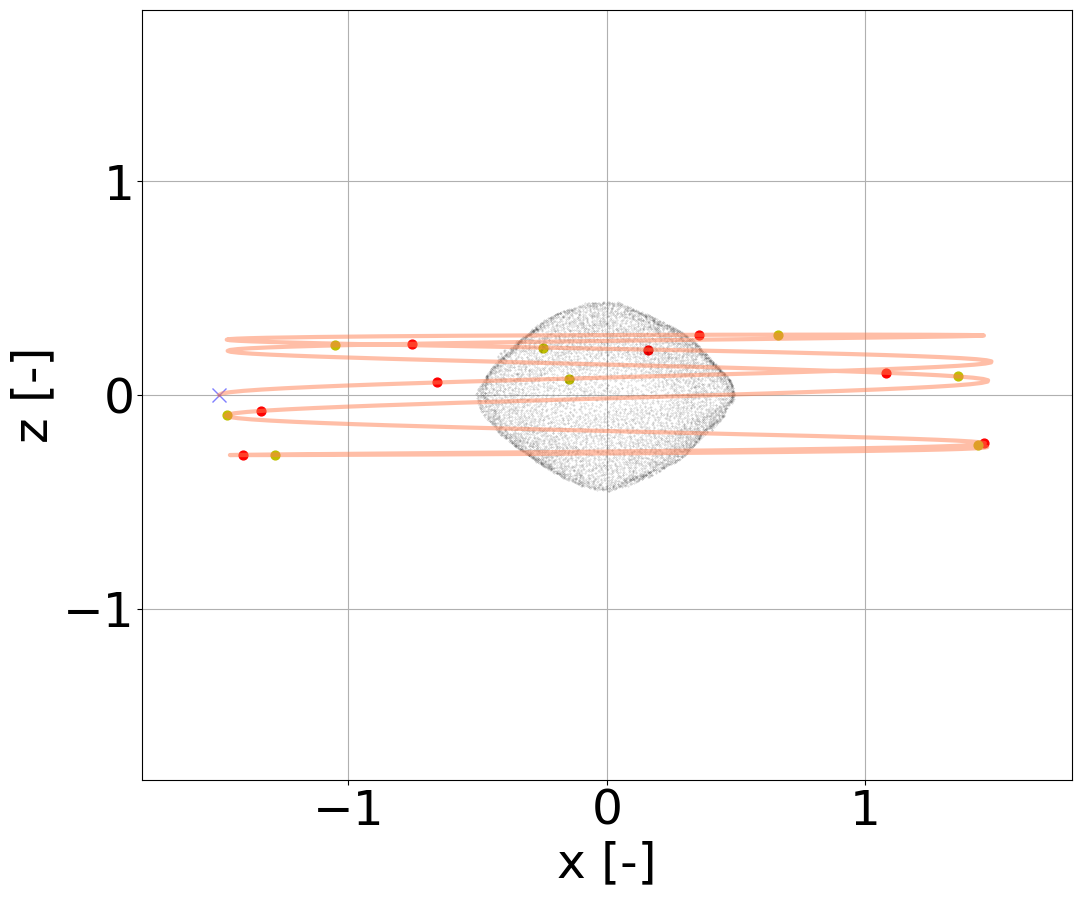

In [25]:
#change fontisze
plt.rcParams.update({'font.size': 35})
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111)

#ax = en.plot_mesh_vertices(mesh_points, 1, s = 1, c='k', alpha=0.1, ax=ax, plot_ref=False, axis_off=False)
two_d=en.project_on_plane(mesh_points,np.array([0,1.,0]))
ax.plot(two_d[0], two_d[1],'x',alpha=0.1,markersize=1.,color='black')
ax.plot(sol2[-1][0,0], sol2[-1][0,2],'x',alpha=0.5,markersize=10.,color='blue')

ax.plot(sol2[-1][:,0], sol2[-1][:,2],  alpha=0.5,linewidth=3.,color='coral')
#ax.plot(sol1[4][:,0], sol1[4][:,1], sol1[4][:,2], 'g')
for idx,t in enumerate(enter_times):
    if idx==0:   
        ax.scatter(t[1][0], t[1][2], s = 40, c = 'r',label='entry')
    else:
        ax.scatter(t[1][0], t[1][2], s = 40, c = 'r')
for idx,t in enumerate(exit_times):
    if idx==0:
        ax.scatter(t[1][0], t[1][2], s = 40, c = 'y',label='exit')
    else:
        ax.scatter(t[1][0], t[1][2], s = 40, c = 'y')

#ax.legend()
ax.set_xlim([-1.8,1.8])
ax.set_ylim([-1.8,1.8])
ax.set_xlabel('x [-]')
ax.set_ylabel('z [-]')
ax.tick_params(axis='x', which='minor', pad=45)
ax.tick_params(axis='y', which='minor', pad=45)

ax.tick_params(axis='x', which='major', pad=2)
ax.tick_params(axis='y', which='major', pad=2)

ax.grid()
fig.savefig(f"orbit_view_{body_name}_2.png",dpi=300)


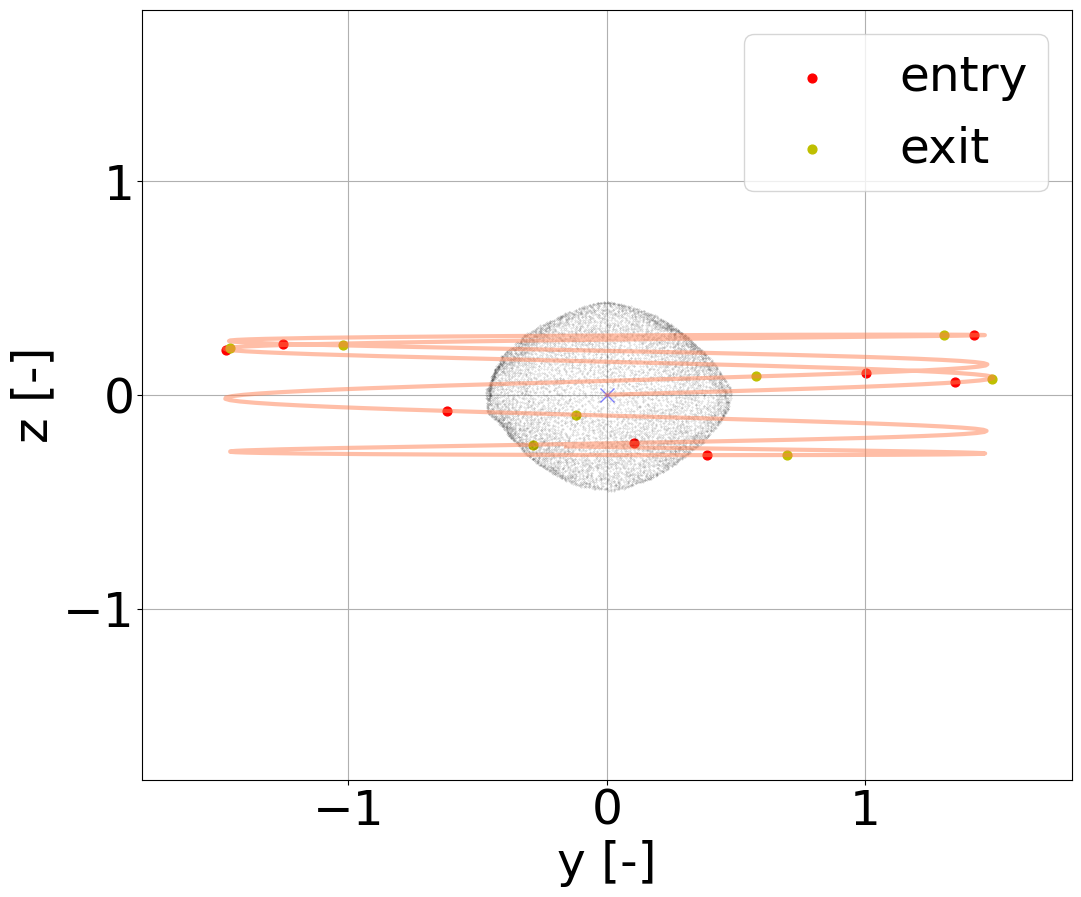

In [26]:
#change fontisze
plt.rcParams.update({'font.size': 35})
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111)

#ax = en.plot_mesh_vertices(mesh_points, 1, s = 1, c='k', alpha=0.1, ax=ax, plot_ref=False, axis_off=False)
two_d=en.project_on_plane(mesh_points,np.array([1.,0,0]))
ax.plot(two_d[0], two_d[1],'x',alpha=0.1,markersize=1.,color='black')
ax.plot(sol2[-1][0,1], sol2[-1][0,2],'x',alpha=0.5,markersize=10.,color='blue')

ax.plot(sol2[-1][:,1], sol2[-1][:,2],  alpha=0.5,linewidth=3.,color='coral')
#ax.plot(sol1[4][:,0], sol1[4][:,1], sol1[4][:,2], 'g')
for idx,t in enumerate(enter_times):
    if idx==0:   
        ax.scatter(t[1][1], t[1][2], s = 40, c = 'r',label='entry')
    else:
        ax.scatter(t[1][1], t[1][2], s = 40, c = 'r')
for idx,t in enumerate(exit_times):
    if idx==0:
        ax.scatter(t[1][1], t[1][2], s = 40, c = 'y',label='exit')
    else:
        ax.scatter(t[1][1], t[1][2], s = 40, c = 'y')

ax.legend()
ax.set_xlim([-1.8,1.8])
ax.set_ylim([-1.8,1.8])
ax.set_xlabel('y [-]')
ax.set_ylabel('z [-]')
ax.tick_params(axis='x', which='minor', pad=45)
ax.tick_params(axis='y', which='minor', pad=45)

ax.tick_params(axis='x', which='major', pad=2)
ax.tick_params(axis='y', which='major', pad=2)

ax.grid()
fig.savefig(f"orbit_view_{body_name}_3.png",dpi=300)


## Scipy with event

In [27]:
#I need the vertices for the Moller Trumbore algo:
v0 = mesh_points[mesh_triangles][:,0]
v1 = mesh_points[mesh_triangles][:,1]
v2 = mesh_points[mesh_triangles][:,2]

In [28]:
def state2input_scipy(position, sun_direction):
    """
    This function takes the spacecraft position and the sun direction 
    and returns the input for the neural network, as numpy objects

    Args:
        position (3,): spacecraft position in cartesian coordinates
        sun_direction (3,): sun direction in cartesian coordinates

    Returns:
        (6,): input for the neural network
    """
    phi=np.arccos(sun_direction[2])
    theta=np.arctan2(sun_direction[1],sun_direction[0])
    costheta=np.cos(theta)
    sintheta=np.sin(theta)
    cosphi=np.cos(phi)
    sinphi=np.sin(phi)
    #now the xy coordinates, defined with a reference system coherent with en.project_on_plane
    U=np.array([-sintheta,costheta,0])
    V=np.array([costheta*cosphi, sintheta*cosphi, -sinphi] )
    # Compute the projection
    X = np.dot(position,U)
    Y = np.dot(position,V)
    return np.array([costheta, sintheta, cosphi, sinphi, X, Y])

In [29]:
def eclipse_trumbore(x,y,z,sd,v0,v1,v2):
    res=en.is_intersecting_v2(np.array([x,y,z]),sd,v0,v1,v2)
    return len(np.where(res==True)[0])>=2


def eclipse_nn(x,y,z,sd,model):
    nn_in = state2input_scipy(np.array([x,y,z]), sd)
    if np.dot(sd,np.array([x,y,z]))>0:
        return False
    if (nn_in[-2]**2+nn_in[-1]**2)<np.sqrt(1.):
        return model(nn_in)<=0.
    else:
        return False

def fun_SRP(t,y):
    x,y,z,vx,vy,vz = y
    dvx=0
    dvy=0
    dvz=0
    diff_x = x-mascon_points[:,0]
    diff_y = y-mascon_points[:,1]
    diff_z = z-mascon_points[:,2]
    r2 = (diff_x)**2+(diff_y)**2+(diff_z)**2
    r3 = r2 * np.sqrt(r2)
    dvx = -np.sum(mascon_masses / r3 * diff_x)
    dvy = -np.sum(mascon_masses / r3 * diff_y)
    dvz = -np.sum(mascon_masses / r3 * diff_z)
    
    sd0 = sun_direction[0] * np.cos(omega * t) - sun_direction[1] * np.sin(omega * t)
    sd1 = sun_direction[0] * np.sin(omega * t) + sun_direction[1] * np.cos(omega * t)
    sd2 = sun_direction[2]
    return [
        vx,
        vy,
        vz,
        dvx - SRP * sd0 + omega**2*x + 2*omega*vy,
        dvy - SRP * sd1 + omega**2*y - 2*omega*vx,
        dvz - SRP * sd2
    ]

def fun_no_SRP(t,y):
    x,y,z,vx,vy,vz = y
    dvx=0
    dvy=0
    dvz=0
    diff_x = x-mascon_points[:,0]
    diff_y = y-mascon_points[:,1]
    diff_z = z-mascon_points[:,2]
    r2 = (diff_x)**2+(diff_y)**2+(diff_z)**2
    r3 = r2 * np.sqrt(r2)
    dvx = -np.sum(mascon_masses / r3 * diff_x)
    dvy = -np.sum(mascon_masses / r3 * diff_y)
    dvz = -np.sum(mascon_masses / r3 * diff_z)
    return [
        vx,
        vy,
        vz,
        dvx + omega**2*x + 2*omega*vy,
        dvy + omega**2*y - 2*omega*vx, 
        dvz 
    ]

def dynamics_srp_and_no_srp(t,y):
    x,y_coord,z,vx,vy,vz = y
    dvx=0
    dvy=0
    dvz=0
    diff_x = x-mascon_points[:,0]
    diff_y = y_coord-mascon_points[:,1]
    diff_z = z-mascon_points[:,2]
    r2 = (diff_x)**2+(diff_y)**2+(diff_z)**2
    r3 = r2 * np.sqrt(r2)
    dvx = -np.sum(mascon_masses / r3 * diff_x)
    dvy = -np.sum(mascon_masses / r3 * diff_y)
    dvz = -np.sum(mascon_masses / r3 * diff_z)

    
    sd0 = sun_direction[0] * np.cos(omega * t) - sun_direction[1] * np.sin(omega * t)
    sd1 = sun_direction[0] * np.sin(omega * t) + sun_direction[1] * np.cos(omega * t)
    sd2 = sun_direction[2]
    sd = np.array([sd0,sd1,sd2])
#    res = en.is_intersecting_v2(y[:3], sd, v0, v1, v2)    
    if eclipse_trumbore(x,y_coord,z,sd,v0,v1,v2):    
        return [vx,vy,vz,dvx + omega**2*x + 2*omega*vy,dvy + omega**2*y_coord - 2*omega*vx, dvz ]
    else:
        return [vx, vy, vz, dvx - SRP * sd0 + omega**2*x + 2*omega*vy, dvy - SRP * sd1 + omega**2*y_coord - 2*omega*vx, dvz - SRP * sd2]

def dynamics_srp_and_no_srp_w_nn(t,y):
    x,y_coord,z,vx,vy,vz = y
    dvx=0
    dvy=0
    dvz=0
    diff_x = x-mascon_points[:,0]
    diff_y = y_coord-mascon_points[:,1]
    diff_z = z-mascon_points[:,2]
    r2 = (diff_x)**2+(diff_y)**2+(diff_z)**2
    r3 = r2 * np.sqrt(r2)
    dvx = -np.sum(mascon_masses / r3 * diff_x)
    dvy = -np.sum(mascon_masses / r3 * diff_y)
    dvz = -np.sum(mascon_masses / r3 * diff_z)

    
    sd0 = sun_direction[0] * np.cos(omega * t) - sun_direction[1] * np.sin(omega * t)
    sd1 = sun_direction[0] * np.sin(omega * t) + sun_direction[1] * np.cos(omega * t)
    sd2 = sun_direction[2]
    sd = np.array([sd0, sd1, sd2])
#    nn_in = state2input_scipy(y[:3], sd)
    if eclipse_nn(x,y_coord,z,sd,model_heyoka_compiled):
        return [vx,vy,vz,dvx + omega**2*x + 2*omega*vy,dvy + omega**2*y_coord - 2*omega*vx, dvz ]
    else:
        return [vx, vy, vz, dvx - SRP * sd0 + omega**2*x + 2*omega*vy, dvy - SRP * sd1 + omega**2*y_coord - 2*omega*vx, dvz - SRP * sd2]



In [30]:
#random initial conditions on a cube of size 3.
count_nn=0
agreements=0
counter=0
count_trumbore=0
while counter<5000:
    x0=np.random.uniform(-1,1)    
    y0=np.random.uniform(-1,1)    
    z0=np.random.uniform(-1,1)    
    if np.sqrt(x0**2+y0**2+z0**2)>np.sqrt(0.4):
        counter+=1
        if eclipse_trumbore(x0,y0,z0,sun_direction,v0,v1,v2) is True:
            count_trumbore+=1
        if eclipse_trumbore(x0,y0,z0,sun_direction,v0,v1,v2)!=eclipse_nn(x0,y0,z0,sun_direction,model_heyoka_compiled):
            print("Discrepancy found!")
            print(x0,y0,z0)
            print(x0,y0,z0, eclipse_trumbore(x0,y0,z0,sun_direction,v0,v1,v2), eclipse_nn(x0,y0,z0,sun_direction,model_heyoka_compiled))


Discrepancy found!
0.34494475275756464 0.682138987370537 -0.33412215224470887
0.34494475275756464 0.682138987370537 -0.33412215224470887 False [ True]
Discrepancy found!
0.6884783197076292 0.22199057515190956 0.26140799235082257
0.6884783197076292 0.22199057515190956 0.26140799235082257 True [False]
Discrepancy found!
0.8424375587767094 0.4055126054315543 0.2810107959045436
0.8424375587767094 0.4055126054315543 0.2810107959045436 True [False]
Discrepancy found!
0.7361982572894599 0.1523067974610124 0.15797184887922766
0.7361982572894599 0.1523067974610124 0.15797184887922766 True [False]
Discrepancy found!
0.25239275951565876 0.6600644737938153 -0.3064946317048107
0.25239275951565876 0.6600644737938153 -0.3064946317048107 True [False]


In [31]:
sc_pos=np.array([0.4950398288422735,0.9589735266112176,0.13616361062608506])

In [32]:
%%timeit
eclipse_trumbore(sc_pos[0],sc_pos[1],sc_pos[2],sun_direction,v0,v1,v2)


1.42 ms ± 169 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [33]:
%%timeit
eclipse_nn(sc_pos[0],sc_pos[1],sc_pos[2],sun_direction,model_heyoka_compiled)

9.16 μs ± 194 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [34]:
vv=en.project_on_plane(sc_pos, sun_direction)
mesh_projected=np.stack(en.project_on_plane(mesh_points, sun_direction))


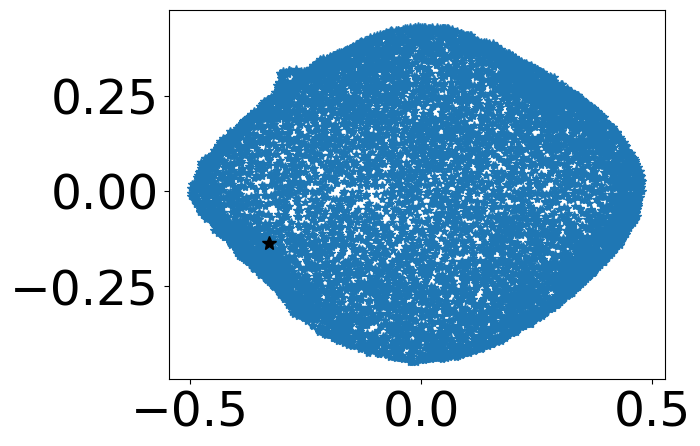

In [35]:
plt.plot(mesh_projected[0,:],mesh_projected[1,:],'*')
plt.plot(vv[0],vv[1],'*',markersize=10,color='black')


In [36]:
dynamics_srp_and_no_srp_w_nn(tgrid[0],ic)

[np.float64(0.0),
 np.float64(4.486669144679322),
 np.float64(0.1557948923352031),
 np.float64(13.440216981510796),
 np.float64(0.0004735883709646554),
 np.float64(-0.0003490701955645658)]

In [37]:

def scipy_event(t,y):
    x,y_coord,z,vx,vy,vz = y
    sd0 = sun_direction[0] * np.cos(omega * t) - sun_direction[1] * np.sin(omega * t)
    sd1 = sun_direction[0] * np.sin(omega * t) + sun_direction[1] * np.cos(omega * t)
    sd2 = sun_direction[2] 
    sd = np.array([sd0, sd1, sd2])
    nn_in = state2input_scipy(y[:3], sd)
    return model_heyoka_compiled(nn_in.reshape(-1,1))[0][0]

scipy_event.terminal = True

# This assumes we start out of the eclipse cone
scipy_event.direction = -1.

In [38]:
scipy_event(t=0.,y=ic)

np.float64(0.05521953625703325)

In [39]:
from scipy.integrate import solve_ivp
# Recording event times
exit_times_scipy = []
enter_times_scipy = []

# Here the logic of switching between dynamics must be implemented outside the integration, 
start = time.time()
# Initial time to integrate piecewise the various segments
t= tgrid[0]
# counter for the actual time reached so far
t_curr = tgrid[0]
# initial conditions
y = ic
sol_all = []
sd = sun_direction
event_time_scipy=[]
while t_curr < tgrid[-1]:
    if np.dot(y[:3], sd) > 0:
        dynamics = fun_SRP
    else:
        if scipy_event.direction == -1:
            dynamics = fun_SRP
        else:
            dynamics = fun_no_SRP
    sol_s = solve_ivp(dynamics, [t, tgrid[-1]], y, method='DOP853', atol=1e-13, rtol=1e-13, events=scipy_event, t_eval=tgrid[(tgrid>=t) & (tgrid<=tgrid[-1])])
    sol_all.append(sol_s)
    t_curr = sol_s.t[-1]
    sd0 = sun_direction[0] * np.cos(omega * t_curr) - sun_direction[1] * np.sin(omega * t_curr)
    sd1 = sun_direction[0] * np.sin(omega * t_curr) + sun_direction[1] * np.cos(omega * t_curr)
    sd2 = sun_direction[2] 
    sd = np.array([sd0,sd1, sd2])
    if sol_s.t_events[0].shape[0] > 0:
        t = sol_s.t_events[0][0]
        y = sol_s.y_events[0][-1]
        res = en.is_intersecting_v2(y[:3], sd, v0, v1, v2)    

        if len(np.where(res==True)[0])>=2:    
            print("event: ", t)
            event_time_scipy.append(t)
        scipy_event.direction *= -1.
end = time.time()
print("Time to propagate without grid: ", end-start)

# Reassembling the solution in one array
tgrid_s = np.array([tgrid[0]])
sol_s = np.array([ic])
for item in sol_all:
    tgrid_s = np.concatenate((tgrid_s, item.t[1:]))
    sol_s = np.concatenate((sol_s, item.y.transpose()[1:,:]))

event:  0.49190348259383
event:  1.628723909100597
event:  2.7719708528232956
event:  3.921607728735487
event:  5.086877118999015
event:  6.238560558917004
event:  7.374041825850868
event:  8.439581486506137
event:  8.514440955536154
Time to propagate without grid:  0.518218994140625


In [40]:
from scipy.integrate import solve_ivp

sol_trumbore = solve_ivp(dynamics_srp_and_no_srp, [tgrid[0],tgrid[-1]], ic, method='DOP853', atol=1e-14, rtol=1e-14,t_eval=tgrid)

/Users/ga00693/miniconda3/envs/eclipsenets/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:505: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  super().__init__(fun, t0, y0, t_bound, max_step, rtol, atol,


In [41]:
sol_nn=solve_ivp(dynamics_srp_and_no_srp_w_nn, [tgrid[0],tgrid[-1]], ic, method='DOP853', atol=1e-13, rtol=1e-13,t_eval=tgrid)

In [42]:
[enter[0] for enter in enter_times], [exit[0] for exit in exit_times],len(enter_times),len(exit_times)

([0.3729819560323955,
  1.536551445223275,
  2.6970501059301997,
  3.836106263287032,
  4.97188247094016,
  6.121232714153214,
  7.283769738318239,
  8.437178868914506],
 [0.4919034825938275,
  1.628750308474693,
  2.772024937652018,
  3.92162862998671,
  5.0867529234361815,
  6.237979322706784,
  7.3728554390871714,
  8.512615284969657],
 8,
 8)

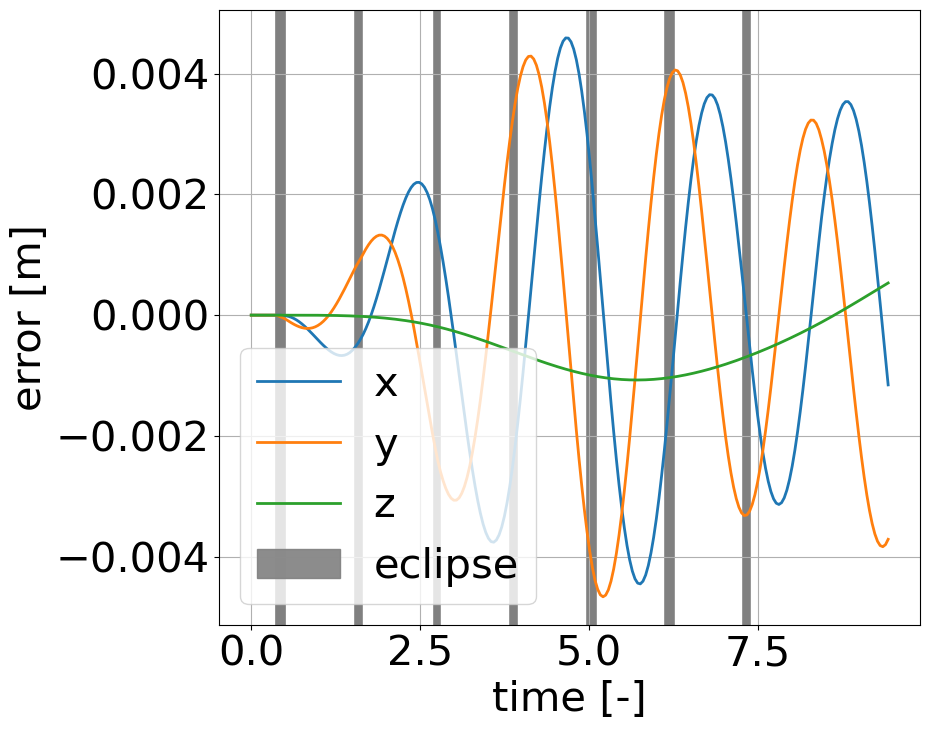

In [43]:
plt.rcParams.update({'font.size': 30})
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)

#ax.plot(tgrid,np.sqrt(sol_nn.y[0,:]**2+sol_nn.y[1,:]**2+sol_nn.y[2,:]**2)-np.sqrt(sol2[-1][:,0]**2+sol2[-1][:,1]**2+sol2[-1][:,2]**2),'-.')
ax.plot(tgrid,L*1e3*(sol2[-1][:,0]-sol_trumbore.y[0,:]),linewidth=2.,label='x')
ax.plot(tgrid,L*1e3*(sol2[-1][:,1]-sol_trumbore.y[1,:]),linewidth=2.,label='y')
ax.plot(tgrid,L*1e3*(sol2[-1][:,2]-sol_trumbore.y[2,:]),linewidth=2.,label='z')
#sol_nn.y[2,:]**2)-np.sqrt(sol2[-1][:,0]**2+sol2[-1][:,1]**2+sol2[-1][:,2]**2),'-.')
#[plt.axvline(enter[0],color='green') for enter in enter_times]
#[plt.axvline(exit[0],color='red') for exit in exit_times]
for i in range(len(enter_times)):
    [ax.axvspan(enter_times[i][0],exit_times[i][0],alpha=0.9,color='gray')for i in range(len(enter_times)-1)]
ax.axvspan(enter_times[0][0],exit_times[0][0],alpha=0.9,color='gray',label='eclipse')
ax.set_xlabel('time [-]')
ax.set_ylabel('error [m]')
ax.legend(loc='lower left')
ax.grid()
fig.tight_layout()#rect=[0.1, 0, 0.9, 1])
fig.savefig(f'positional_errors_{body_name}.png',dpi=300)


/var/folders/vf/cj60m8k162316snsvmjw65280000gp/T/ipykernel_94107/786315273.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


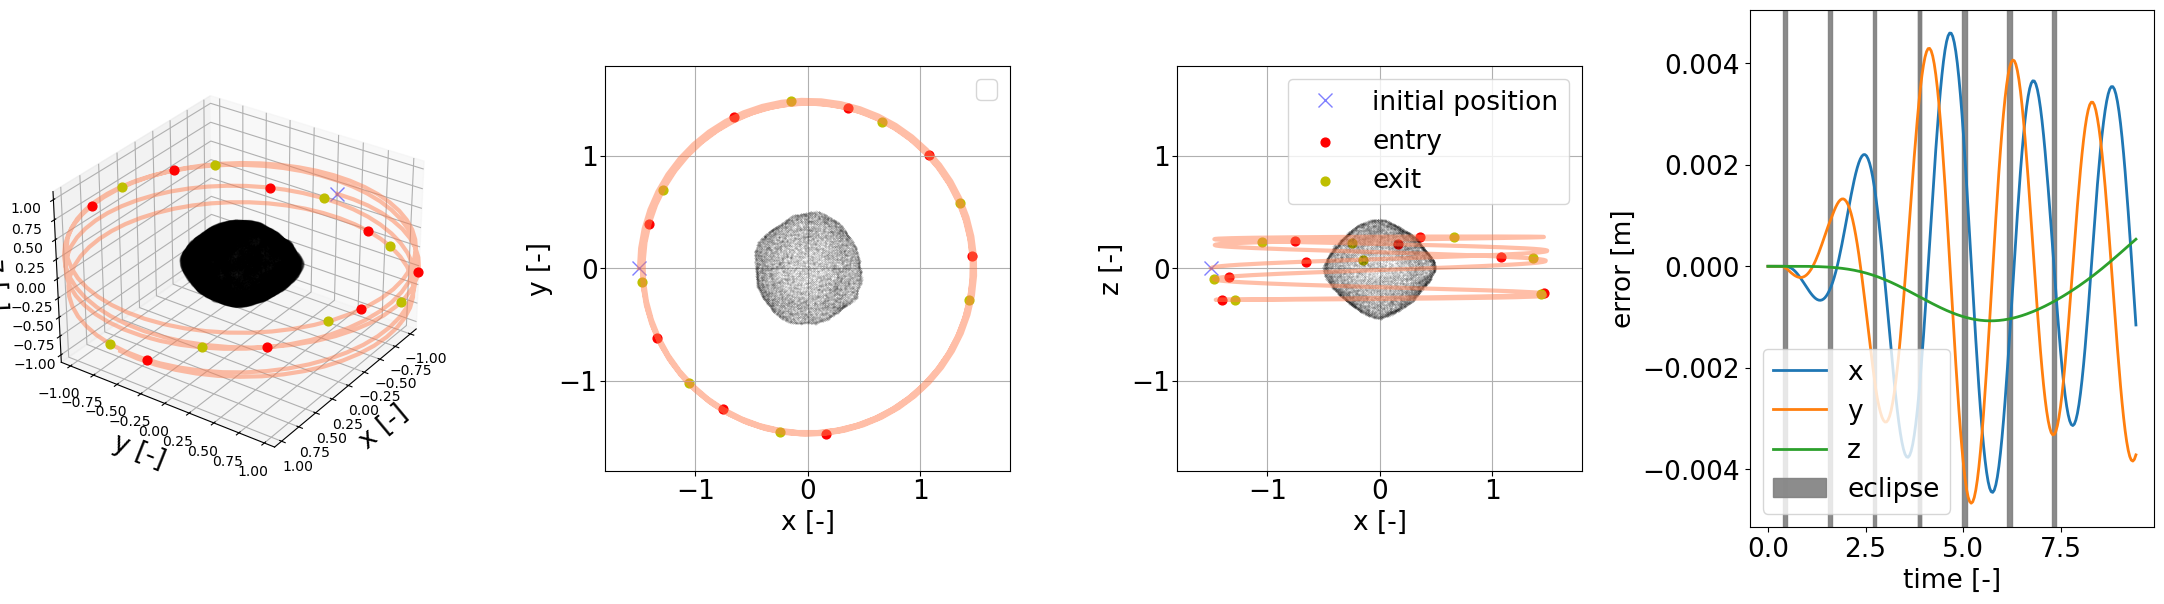

In [44]:
plt.rcParams.update({'font.size': 19})
fig = plt.figure(figsize=(22,18))
# Add 3D scatter plots to the first row
for i in range(4):
    if i==0:
        ax = fig.add_subplot(3, 4, i + 1, projection='3d')

        # Plot the 3D figure in the first subplot
        ax = en.plot_mesh_vertices(mesh_points, 1,  c='k', alpha=0.1, ax=ax, plot_ref=False, axis_off=False)
        ax.plot(sol2[-1][0, 0], sol2[-1][0, 1], sol2[-1][0, 2], 'x', alpha=0.5, markersize=10., color='blue')
        ax.plot(sol2[-1][:, 0], sol2[-1][:, 1], sol2[-1][:, 2], alpha=0.5, linewidth=3., color='coral')

        for t in enter_times:
            ax.scatter(t[1][0], t[1][1], t[1][2], s=40, c='r')
        for t in exit_times:
            ax.scatter(t[1][0], t[1][1], t[1][2], s=40, c='y')

        ax.set_xlim([-1.1, 1.1])
        ax.set_ylim([-1.1, 1.1])
        ax.set_zlim([-1.1, 1.1])
        ax.set_xlabel('x [-]')
        ax.set_ylabel('y [-]')
        ax.set_zlabel('z [-]')
        ax.tick_params(axis='y', which='minor', pad=45)
        ax.tick_params(axis='x', which='minor', pad=45)
        ax.tick_params(axis='z', which='minor', pad=45)
        ax.tick_params(axis='x', which='major', pad=3, labelsize=10)
        ax.tick_params(axis='y', which='major', pad=3, labelsize=10)
        ax.tick_params(axis='z', which='major', pad=3, labelsize=10)
        ax.view_init(30, 35)        
        fig.tight_layout()

    if i==1:
        ax = fig.add_subplot(3, 4, i + 1, )
        #ax = en.plot_mesh_vertices(mesh_points, 1, s = 1, c='k', alpha=0.1, ax=ax, plot_ref=False, axis_off=False)
        two_d=en.project_on_plane(mesh_points,np.array([0,0,1.]))
        ax.plot(two_d[0], two_d[1],'x',alpha=0.1,markersize=1.,color='black')
        ax.plot(sol2[-1][0,0], sol2[-1][0,1],'x',alpha=0.5,markersize=10.,color='blue')

        ax.plot(sol2[-1][:,0], sol2[-1][:,1],  alpha=0.5,linewidth=3.,color='coral')
        #ax.plot(sol1[4][:,0], sol1[4][:,1], sol1[4][:,2], 'g')
        for idx,t in enumerate(enter_times):
            ax.scatter(t[1][0], t[1][1], s = 40, c = 'r')
        for idx,t in enumerate(exit_times):
            ax.scatter(t[1][0], t[1][1], s = 40, c = 'y')

        ax.legend()
        ax.set_xlim([-1.8,1.8])
        ax.set_ylim([-1.8,1.8])
        ax.set_xlabel('x [-]')
        ax.set_ylabel('y [-]')
        ax.tick_params(axis='y', which='minor', pad=45)
        ax.tick_params(axis='x', which='minor', pad=45)

        ax.tick_params(axis='x', which='major', pad=2)
        ax.tick_params(axis='y', which='major', pad=2)
        fig.tight_layout()
        ax.set_aspect('equal')

        ax.grid()

    if i==2:
        ax = fig.add_subplot(3, 4, i + 1, )
        #ax = en.plot_mesh_vertices(mesh_points, 1, s = 1, c='k', alpha=0.1, ax=ax, plot_ref=False, axis_off=False)
        two_d=en.project_on_plane(mesh_points,np.array([0,1.,0]))
        ax.plot(two_d[0], two_d[1],'x',alpha=0.1,markersize=1.,color='black')
        ax.plot(sol2[-1][0,0], sol2[-1][0,2],'x',alpha=0.5,markersize=10.,color='blue',label='initial position')

        ax.plot(sol2[-1][:,0], sol2[-1][:,2],  alpha=0.5,linewidth=3.,color='coral')
        #ax.plot(sol1[4][:,0], sol1[4][:,1], sol1[4][:,2], 'g')
        for idx,t in enumerate(enter_times):
            if idx==0:   
                ax.scatter(t[1][0], t[1][2], s = 40, c = 'r',label='entry')
            else:
                ax.scatter(t[1][0], t[1][2], s = 40, c = 'r')
        for idx,t in enumerate(exit_times):
            if idx==0:
                ax.scatter(t[1][0], t[1][2], s = 40, c = 'y',label='exit')
            else:
                ax.scatter(t[1][0], t[1][2], s = 40, c = 'y')

        ax.legend()
        ax.set_xlim([-1.8,1.8])
        ax.set_ylim([-1.8,1.8])
        ax.set_xlabel('x [-]')
        ax.set_ylabel('z [-]')
        ax.tick_params(axis='y', which='minor', pad=45)
        ax.tick_params(axis='x', which='minor', pad=45)

        ax.tick_params(axis='x', which='major', pad=2)
        ax.tick_params(axis='y', which='major', pad=2)
        fig.tight_layout()
        ax.set_aspect('equal')

        ax.grid()
    if i==3:
        ax = fig.add_subplot(3, 4, i + 1, )

        #ax.plot(tgrid,np.sqrt(sol_nn.y[0,:]**2+sol_nn.y[1,:]**2+sol_nn.y[2,:]**2)-np.sqrt(sol2[-1][:,0]**2+sol2[-1][:,1]**2+sol2[-1][:,2]**2),'-.')
        ax.plot(tgrid,L*1e3*(sol_nn.y[0,:]-sol_trumbore.y[0,:]),linewidth=2.,label='x')
        ax.plot(tgrid,L*1e3*(sol_nn.y[1,:]-sol_trumbore.y[1,:]),linewidth=2.,label='y')
        ax.plot(tgrid,L*1e3*(sol_nn.y[2,:]-sol_trumbore.y[2,:]),linewidth=2.,label='z')
        #sol_nn.y[2,:]**2)-np.sqrt(sol2[-1][:,0]**2+sol2[-1][:,1]**2+sol2[-1][:,2]**2),'-.')
        #[plt.axvline(enter[0],color='green') for enter in enter_times]
        #[plt.axvline(exit[0],color='red') for exit in exit_times]
        [ax.axvspan(enter_times[i][0],exit_times[i][0],alpha=0.9,color='gray')for i in range(len(enter_times)-1)]
        ax.axvspan(enter_times[i][0],exit_times[i][0],alpha=0.9,color='gray',label='eclipse')
        ax.set_xlabel('time [-]')
        ax.set_ylabel('error [m]')
        ax.legend(loc='lower left')
        
    fig.tight_layout()#rect=[0.1, 0, 0.9, 1])
    fig.savefig('fig.png',dpi=300)


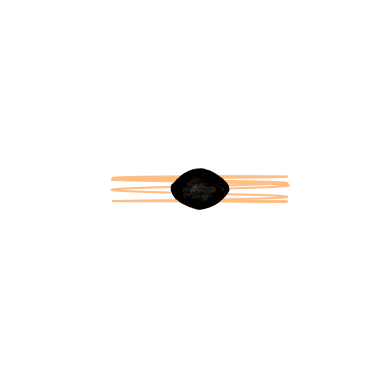

In [45]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(sol_s[0,0], sol_s[0,1], sol_s[0,2], 'x',alpha=0.5)

ax.plot(sol_s[:,0], sol_s[:,1], sol_s[:,2], alpha=0.5)
ax = en.plot_mesh_vertices(mesh_points, 1, s = 1, c='k', alpha=0.1, ax=ax)
ax.axis("off")
ax.set_xlim([-2,2])
ax.set_ylim([-2,2])
ax.set_zlim([-2,2])
phi = np.arccos(sun_direction[2]) 
theta = np.arcsin(sun_direction[1] / np.sin(phi)) 
ax.view_init(0,0)